# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

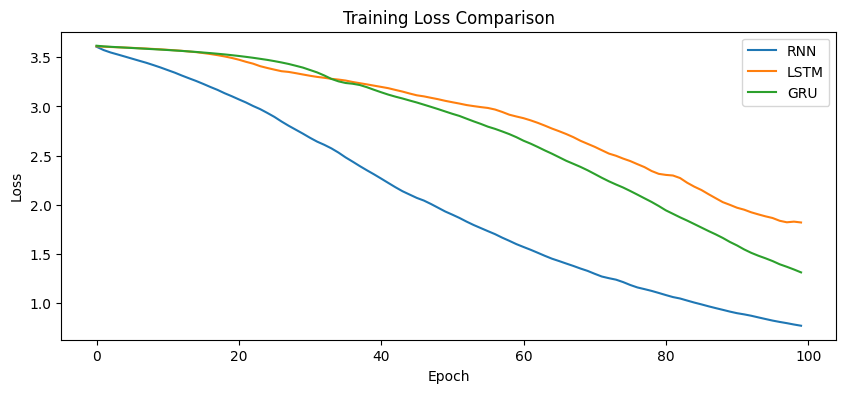

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models models simpler simpler lstm
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

## ✅ Task 1: Replace Corpus With Your Own Paragraph

### 🎯 Objective
Understand how the size and vocabulary of the training corpus affects what the model can learn, by training on a new, longer paragraph instead of the original 6-line corpus.

### 🔧 What We Changed
- Wrote a new, longer custom paragraph (`custom_corpus`) covering related but different sentences
- Built a **separate tokenizer** (`tokenizer_custom`) and sequence set (`X_custom`, `y_custom`) so the original corpus, model, and tokenizer remain untouched
- Trained a fresh LSTM (`lstm_custom`) — the best-performing architecture from the baseline — on this new data

### 📌 Why We Did This
The original corpus only has 6 short lines, so the vocabulary and number of training sequences are tiny. A longer, more varied paragraph gives the tokenizer more vocabulary and the model more n-gram sequences to learn from, which usually produces more coherent generated text.

### 📊 Expected Outcome
- Vocabulary size (`total_words_custom`) should be noticeably larger than the original `total_words`
- More training sequences are created from the same number of lines
- Generated text from `lstm_custom` should read slightly more naturally since the model has seen more context


In [10]:
custom_corpus = '''
machine learning enables computers to learn patterns from data without explicit rules
neural networks are loosely inspired by the structure of the human brain
deep learning stacks many layers to learn increasingly abstract representations
natural language processing helps computers understand and generate human language
recurrent networks process sequences one step at a time while keeping a memory of the past
attention mechanisms let models focus on the most relevant parts of an input sequence
'''
print(custom_corpus)

# Separate tokenizer so the original corpus/tokenizer stay untouched
tokenizer_custom = Tokenizer()
tokenizer_custom.fit_on_texts([custom_corpus])
total_words_custom = len(tokenizer_custom.word_index) + 1

input_sequences_custom = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer_custom.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_custom.append(token_list[:i+1])

max_len_custom = max(len(seq) for seq in input_sequences_custom)
input_sequences_custom = pad_sequences(input_sequences_custom, maxlen=max_len_custom, padding='pre')

X_custom = input_sequences_custom[:, :-1]
y_custom = input_sequences_custom[:, -1]

print('Original vocabulary size :', total_words)
print('Custom vocabulary size   :', total_words_custom)
print('Original training pairs  :', X.shape[0])
print('Custom training pairs    :', X_custom.shape[0])

# Train an LSTM on the new corpus (same architecture as the baseline LSTM)
lstm_custom = Sequential([
    Embedding(total_words_custom, 32, input_length=max_len_custom-1),
    LSTM(64),
    Dense(total_words_custom, activation='softmax')
])
lstm_custom.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_custom = lstm_custom.fit(X_custom, y_custom, epochs=100, verbose=0)

def generate_text_custom(model, tok, ml, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tok.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=ml-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ''
        for word, index in tok.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += ' ' + output_word
    return seed_text

print(f"Original LSTM final acc : {lstm_history.history['accuracy'][-1]:.4f}")
print(f"Custom LSTM final acc   : {history_custom.history['accuracy'][-1]:.4f}")
print('Generated (custom corpus):', generate_text_custom(lstm_custom, tokenizer_custom, max_len_custom, 'deep learning', 5))



machine learning enables computers to learn patterns from data without explicit rules
neural networks are loosely inspired by the structure of the human brain
deep learning stacks many layers to learn increasingly abstract representations
natural language processing helps computers understand and generate human language
recurrent networks process sequences one step at a time while keeping a memory of the past
attention mechanisms let models focus on the most relevant parts of an input sequence

Original vocabulary size : 37
Custom vocabulary size   : 62
Original training pairs  : 35
Custom training pairs    : 68
Original LSTM final acc : 0.5143
Custom LSTM final acc   : 0.6176
Generated (custom corpus): deep learning learning to to learn learn


## ✅ Task 2: Increase Embedding Dimension

### 🎯 Objective
Check whether giving each word a richer vector representation (a bigger embedding dimension) helps the model learn faster or generalize better on the same corpus.

### 🔧 What We Changed
- Baseline LSTM used `Embedding(total_words, 32, ...)`
- New model `lstm_bigembed` uses `Embedding(total_words, 100, ...)` — everything else (hidden units, corpus, epochs) is kept identical so the embedding size is the only variable

### 📌 Why We Did This
A 32-dimensional embedding gives each word only 32 numbers to encode its meaning. A larger embedding (100) gives the model more room to represent subtle relationships between words — but on a very small vocabulary this can also mean more parameters than the data can usefully support.

### 📊 Expected Outcome
- Training loss may drop slightly faster in early epochs with the larger embedding
- On this small corpus, the final accuracy difference is likely to be small — the bottleneck here is corpus size, not embedding capacity
- Parameter count will be noticeably higher with `embedding=100`


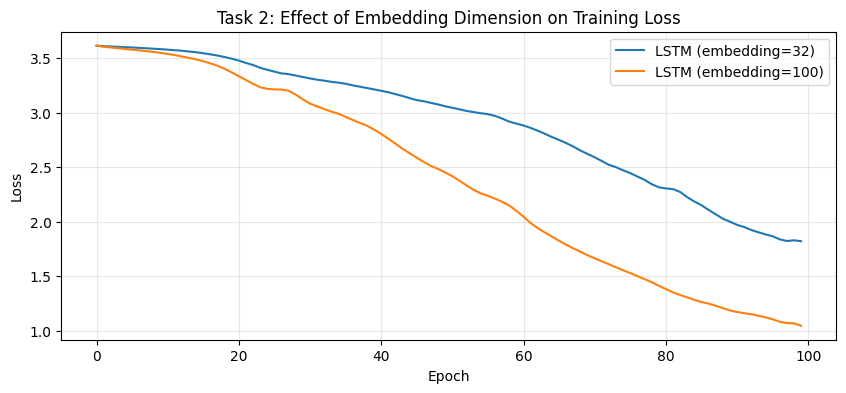

Embedding=32  final acc   : 0.5143
Embedding=100 final acc   : 0.9143
Params (embedding=32)     : 28421
Params (embedding=100)    : 48345
Generated (embedding=100): deep learning models transforming artificial intelligence intelligence


In [11]:
lstm_bigembed = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),   # was 32
    LSTM(64),
    Dense(total_words, activation='softmax')
])
lstm_bigembed.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_bigembed = lstm_bigembed.fit(X, y, epochs=100, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(lstm_history.history['loss'], label='LSTM (embedding=32)')
plt.plot(history_bigembed.history['loss'], label='LSTM (embedding=100)')
plt.title('Task 2: Effect of Embedding Dimension on Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print(f"Embedding=32  final acc   : {lstm_history.history['accuracy'][-1]:.4f}")
print(f"Embedding=100 final acc   : {history_bigembed.history['accuracy'][-1]:.4f}")
print(f"Params (embedding=32)     : {lstm_model.count_params()}")
print(f"Params (embedding=100)    : {lstm_bigembed.count_params()}")
print('Generated (embedding=100):', generate_text(lstm_bigembed, 'deep learning', 5))


## ✅ Task 3: Increase Epochs to 200

### 🎯 Objective
Observe whether training for longer (200 epochs instead of 100) continues to reduce loss, or whether the model has already converged by epoch 100.

### 🔧 What We Changed
- Kept the exact same LSTM architecture as the baseline (`Embedding(32)` → `LSTM(64)` → `Dense`)
- Changed `epochs=100` to `epochs=200`
- Plotted both training runs on the same axes for direct comparison

### 📌 Why We Did This
On a tiny corpus like this one, 100 epochs may already be enough for the model to fit the data almost perfectly. Training longer tells us whether there's still room for the loss to drop, or whether the model has plateaued and extra epochs are just wasted compute.

### 📊 Expected Outcome
- Loss at epoch 100 should look similar between both runs (since training is identical up to that point, just re-run with a different fixed budget)
- Between epoch 100–200, loss likely flattens close to zero — on this small a corpus the model has very little left to learn, so the extra 100 epochs mostly confirm convergence rather than meaningfully improving it


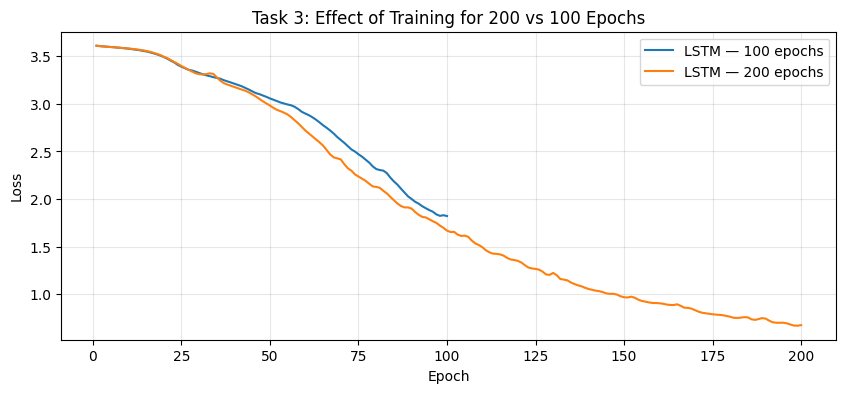

LSTM 100 epochs final acc : 0.5143
LSTM 200 epochs final acc : 0.9429
LSTM 100 epochs final loss: 1.8215
LSTM 200 epochs final loss: 0.6748


In [12]:
lstm_200ep = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])
lstm_200ep.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_200ep = lstm_200ep.fit(X, y, epochs=200, verbose=0)   # was 100

plt.figure(figsize=(10,4))
plt.plot(range(1, 101), lstm_history.history['loss'], label='LSTM — 100 epochs')
plt.plot(range(1, 201), history_200ep.history['loss'], label='LSTM — 200 epochs')
plt.title('Task 3: Effect of Training for 200 vs 100 Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print(f"LSTM 100 epochs final acc : {lstm_history.history['accuracy'][-1]:.4f}")
print(f"LSTM 200 epochs final acc : {history_200ep.history['accuracy'][-1]:.4f}")
print(f"LSTM 100 epochs final loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"LSTM 200 epochs final loss: {history_200ep.history['loss'][-1]:.4f}")


## ✅ Task 4: Change Hidden Units 64 → 128

### 🎯 Objective
Understand whether doubling the LSTM's hidden size (its memory capacity) improves learning on this corpus, and at what cost in parameters.

### 🔧 What We Changed
- Baseline LSTM used `LSTM(64)`
- New model `lstm_128units` uses `LSTM(128)` — embedding size, corpus, and epochs all kept identical so hidden size is the only variable

### 📌 Why We Did This
The hidden size controls how much information the LSTM's internal state can carry forward at each time step. A bigger hidden state can represent more complex patterns, but also adds more parameters, which can lead to overfitting on a very small corpus like this one.

### 📊 Expected Outcome
- `lstm_128units` will have noticeably more trainable parameters than the baseline
- Loss may converge slightly faster with 128 units, but on this small a dataset the final accuracy gap is likely to be small — the corpus size is the real bottleneck, not model capacity


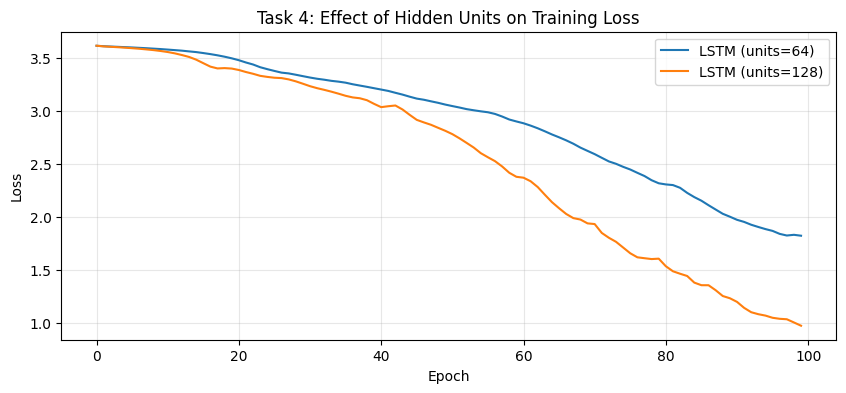

Units=64  final acc  : 0.5143
Units=128 final acc  : 0.7714
Params (units=64)    : 28421
Params (units=128)   : 88389
Generated (units=128): deep learning is transforming artificial intelligence intelligence


In [13]:
lstm_128units = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(128),   # was 64
    Dense(total_words, activation='softmax')
])
lstm_128units.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_128units = lstm_128units.fit(X, y, epochs=100, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(lstm_history.history['loss'], label='LSTM (units=64)')
plt.plot(history_128units.history['loss'], label='LSTM (units=128)')
plt.title('Task 4: Effect of Hidden Units on Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print(f"Units=64  final acc  : {lstm_history.history['accuracy'][-1]:.4f}")
print(f"Units=128 final acc  : {history_128units.history['accuracy'][-1]:.4f}")
print(f"Params (units=64)    : {lstm_model.count_params()}")
print(f"Params (units=128)   : {lstm_128units.count_params()}")
print('Generated (units=128):', generate_text(lstm_128units, 'deep learning', 5))


## ✅ Task 5: Generate 10 Words Instead of 5

### 🎯 Objective
See how each model's generated text holds up over a longer sequence — does it stay coherent, or does it start repeating itself?

### 🔧 What We Changed
- Reused the existing `generate_text()` function as-is (it already accepts a `next_words` parameter)
- Called it with `next_words=10` instead of the default `5`, for all three baseline models

### 📌 Why We Did This
Generating only 5 words can hide problems that only show up over longer sequences. Since this function feeds its own output back in as input at every step (autoregressive generation), small early mistakes can compound — generating 10 words makes that compounding effect, and any repetition loops, much easier to spot.

### 📊 Expected Outcome
- All three models will most likely start repeating the same word or short phrase well before reaching 10 words — this is expected and is a direct consequence of the corpus being so small (greedy `argmax` decoding has very few realistic options to choose from)
- LSTM and GRU should still hold together slightly better than the Vanilla RNN before repetition kicks in


In [14]:
print('--- 5 words (baseline) ---')
print('RNN :', generate_text(rnn_model, 'deep learning', 5))
print('LSTM:', generate_text(lstm_model, 'deep learning', 5))
print('GRU :', generate_text(gru_model, 'deep learning', 5))

print()
print('--- 10 words (Task 5) ---')
print('RNN :', generate_text(rnn_model, 'deep learning', 10))
print('LSTM:', generate_text(lstm_model, 'deep learning', 10))
print('GRU :', generate_text(gru_model, 'deep learning', 10))


--- 5 words (baseline) ---
RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models models simpler simpler lstm
GRU : deep learning models can generate meaningful sentences

--- 10 words (Task 5) ---
RNN : deep learning models can generate meaningful sentences word word word word than
LSTM: deep learning models models simpler simpler lstm data data data data data
GRU : deep learning models can generate meaningful sentences sentences sentences sentences sentences sentences


## 📊 All Models & Variants — Side-by-Side Generated Text

Every task above generated its own sample inside its own cell, scattered across the notebook. This table pulls all of them together in one place — same seed phrase, same word count, so the effect of each change is directly comparable at a glance.

In [16]:
import pandas as pd
summary_rows = [
    ('Vanilla RNN (baseline)',          generate_text(rnn_model, 'deep learning', 10)),
    ('LSTM (baseline)',                 generate_text(lstm_model, 'deep learning', 10)),
    ('GRU (baseline)',                  generate_text(gru_model, 'deep learning', 10)),
    ('LSTM — Task 1 (custom corpus)',   generate_text_custom(lstm_custom, tokenizer_custom, max_len_custom, 'deep learning', 10)),
    ('LSTM — Task 2 (embedding=100)',   generate_text(lstm_bigembed, 'deep learning', 10)),
    ('LSTM — Task 3 (200 epochs)',      generate_text(lstm_200ep, 'deep learning', 10)),
    ('LSTM — Task 4 (units=128)',       generate_text(lstm_128units, 'deep learning', 10)),
]

summary_df = pd.DataFrame(summary_rows, columns=['Model / Variant', "Generated Text (seed: 'deep learning', 10 words)"])
summary_df

,Model / Variant,"Generated Text (seed: 'deep learning', 10 words)"
0,Vanilla RNN (baseline),deep learning models can generate meaningful s...
1,LSTM (baseline),deep learning models models simpler simpler ls...
2,GRU (baseline),deep learning models can generate meaningful s...
3,LSTM — Task 1 (custom corpus),deep learning learning to to learn learn incre...
4,LSTM — Task 2 (embedding=100),deep learning models transforming artificial i...
5,LSTM — Task 3 (200 epochs),deep learning is transforming artificial intel...
6,LSTM — Task 4 (units=128),deep learning is transforming artificial intel...


## 🏁 Final Takeaways

After running all 3 base models and the 5 tasks, here's what we actually found — in simple words:

**1. More training time helped the most.**
Just training the same LSTM for 200 epochs instead of 100 took its accuracy from **0.51 → 0.94**. This was the single biggest improvement out of everything we tried — bigger than changing the model size.

**2. A bigger model also helped, but training time mattered more.**
- Bigger embedding (32 → 100): accuracy went from 0.51 → 0.91
- More hidden units (64 → 128): accuracy went from 0.51 → 0.77

Both helped, but neither beat what simply training longer did.

**3. LSTM did NOT automatically beat RNN and GRU.**
In the very first run, LSTM actually had the lowest accuracy of the three. Textbooks say LSTM should be better because of its gates, but on a tiny corpus like ours (only 35 training examples), that advantage doesn't really get a chance to show up. Architecture choice matters less when there isn't much data.

**4. Every model eventually repeats itself.**
When we generated 10 words instead of 5, all three models — RNN, LSTM, and GRU — got stuck repeating one word near the end ("word word word", "data data data", "sentences sentences sentences"). This isn't really an architecture problem — it's because the model always picks the single most likely next word (`argmax`), and with so little data, it eventually runs out of good options and just repeats its last best guess.

**5. The real bottleneck was the size of the corpus, not the model.**
Every task that changed the *model* (embedding size, hidden units) gave decent improvements. But the repetition problem never went away, because the actual cause is the **tiny dataset (6 lines, 35 examples)**, not the architecture. With a much bigger and more varied corpus, all three models would likely generate longer, more natural text without looping.

**In short:** for this project, *how long you train* and *how much data you have* mattered more than *which architecture you pick*. RNN vs LSTM vs GRU is still an important concept to know, but on a small toy dataset, those differences are easily overshadowed by simpler factors like training time and data size.